In [1]:
import pandas as pd 
import numpy as  np 
import matplotlib.pyplot as   plt 
import seaborn as sns

import sys

sys.path.append('./source')
from sklearn.model_selection import train_test_split


## Importation des fonctions


In [13]:
from  onlineMROTauc_eval import OnlineMROTAD
from offline import OfflineMROT
from utils import plot_auc_over_time, plot_auc_with_drift, split_data


In [3]:
s1 = pd.read_csv("./datasets/cao2025/S1.csv")

In [4]:
data = s1.iloc[:,:-2]

drift_labels = s1.iloc[:,-1]
true_labels = s1.iloc[:,-2]

In [5]:
X_train, X_test, y_drift_train, y_drift_test, y_true_train, y_true_test = split_data(data, drift_labels, true_labels, n_train_samples=2000)

In [6]:
od = online = OnlineMROTAD(
    mrot_params={},
    window_size=200,
    n_history=5,            
    m_barycenter=3,
    theta_validation=0.80,
    tau_anomaly=0.75,
    K_retrain=5,
    data_online=pd.DataFrame(X_test, columns=data.columns),
    y_true_online=y_true_test,
    data_offline=pd.DataFrame(X_train, columns=data.columns),
    y_true_offline=y_true_train,
    drift_threshold=0.5
)       

Anomaly scores for initial data computed. AUC Score: 0.9932116996951219


In [7]:
result = od.online_tumbling_window()

 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!


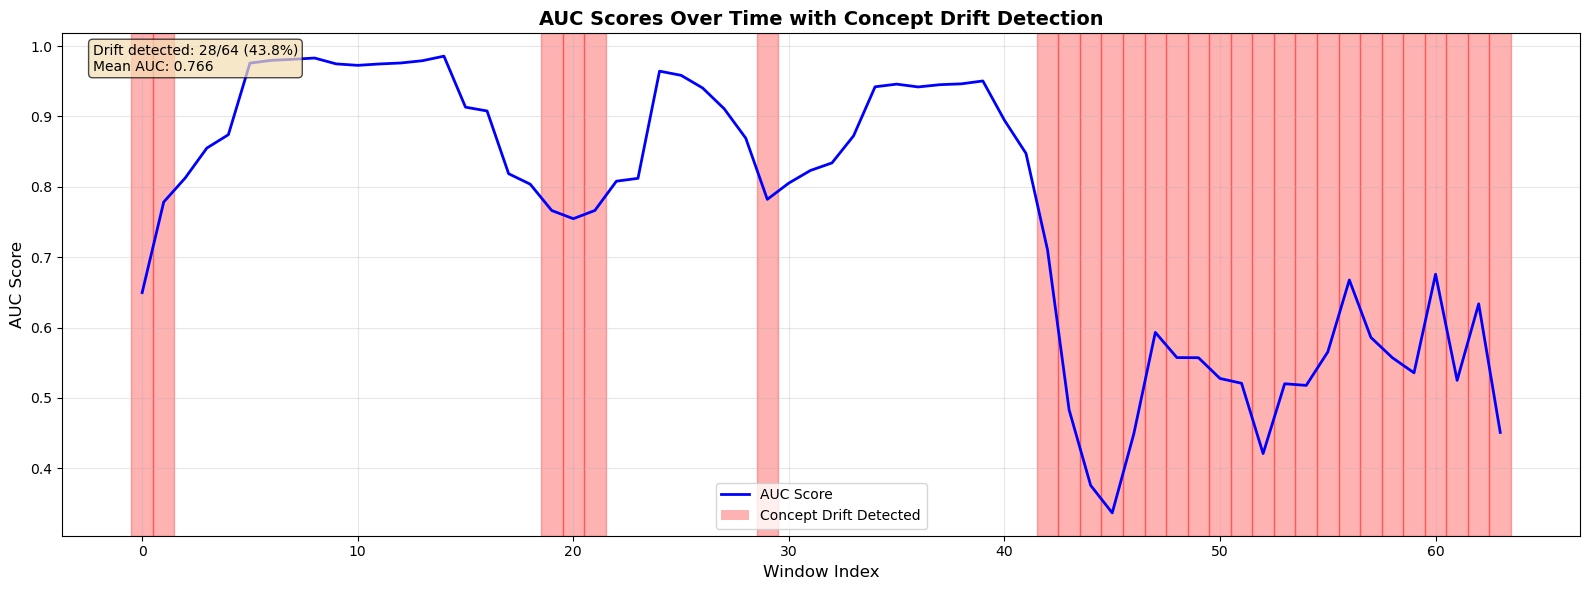

(<Figure size 1600x600 with 1 Axes>,
 <Axes: title={'center': 'AUC Scores Over Time with Concept Drift Detection'}, xlabel='Window Index', ylabel='AUC Score'>)

In [8]:
auc_lists = result[0]
drift_indicators = result[1] 


plot_auc_with_drift(auc_lists, drift_indicators)

In [9]:
result2 = od.online_sliding_window()

 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model r

In [10]:
len(auc_lists)

64

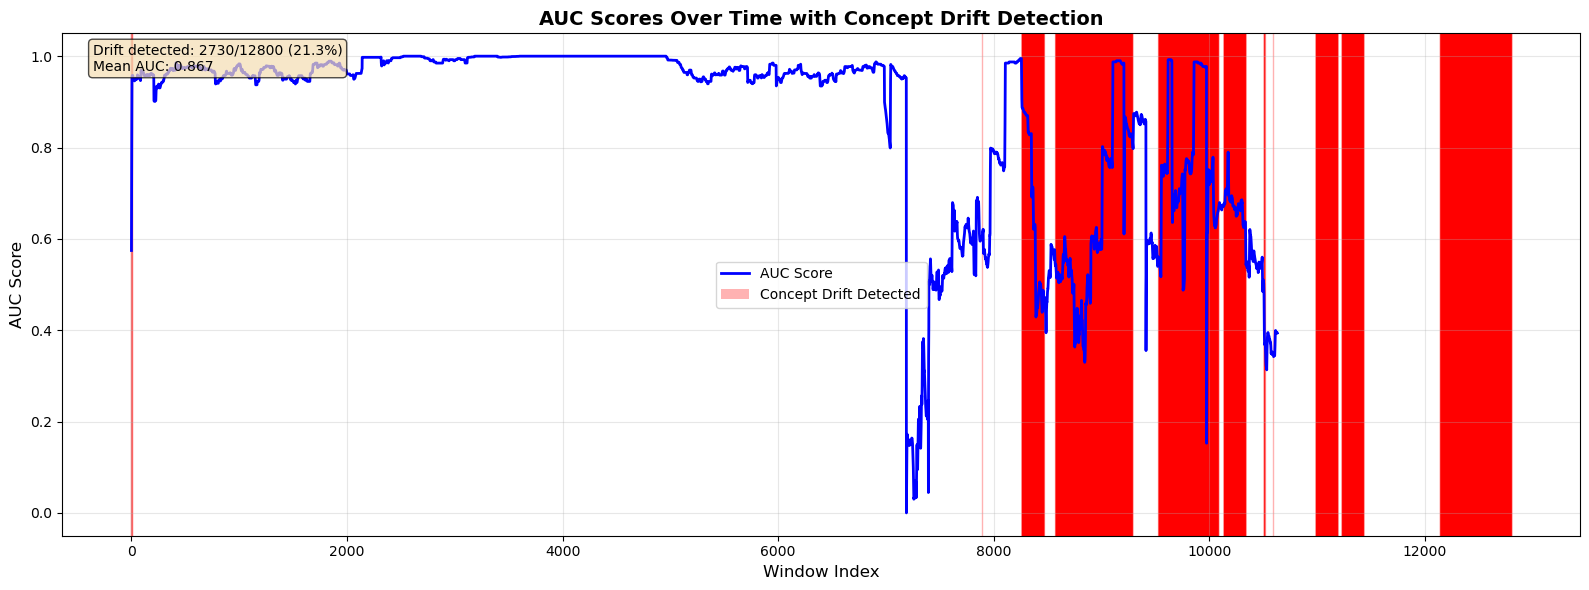

(<Figure size 1600x600 with 1 Axes>,
 <Axes: title={'center': 'AUC Scores Over Time with Concept Drift Detection'}, xlabel='Window Index', ylabel='AUC Score'>)

In [12]:
auc_lists = result2[0]
drift_indicators = result2[1] 


plot_auc_with_drift(auc_lists, drift_indicators)